# Model Tuning

Коротко: тюним лучшие модели через Optuna, сохраняем study-кэш и финальную модель.


## Setup / Настройка


In [1]:
# База / core
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from catboost import CatBoostClassifier
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances

# Sklearn / ML
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Корень проекта / project root
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "requirements.txt").exists())

# Стиль / style
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 70)
plt.rcParams["figure.figsize"] = (8, 4)


## Data / Данные


In [2]:
# Данные после FE / data after feature engineering
df_model = pd.read_parquet(ROOT / "data" / "titanic_fe.parquet")

X = df_model.drop(columns="survived")
y = df_model["survived"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)


## Preprocessing / Предобработка


In [3]:
# Features & preprocessing
numeric_features = X_train.select_dtypes(include="number").columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category", "string"]).columns.tolist()

preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), categorical_features)
])

## Tuning Cache / Кэш


In [4]:
# Кэш тюнинга / tuning cache
MODELS_DIR = ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)


def get_or_run_study(name, objective, n_trials=50):
    """Загружаем study из кэша или запускаем Optuna / load cache or run Optuna."""
    path = MODELS_DIR / f"study_{name}.pkl"

    if path.exists():
        study = joblib.load(path)
        print(f"[{name}] загружен из кэша ({len(study.trials)} trials) — тюнинг пропущен.")
        return study

    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials)
    joblib.dump(study, path)
    print(f"[{name}] тюнинг завершён, study сохранён → {path.name}")
    return study


## RandomForest / Случайный лес


In [5]:
def objective_rf(trial):
    model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=trial.suggest_int("n_estimators", 100, 1500),
            max_depth=trial.suggest_int("max_depth", 3, 20),
            min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
            min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10),
            max_features=trial.suggest_categorical("max_features", ["sqrt", "log2"]),
            random_state=42, n_jobs=-1
        ))
    ])

    return cross_val_score(
        model, X_train, y_train,
        cv=5, scoring="accuracy", n_jobs=-1
    ).mean()


study_rf = get_or_run_study("rf", objective_rf, n_trials=50)

print("Best score:", study_rf.best_value)
print("Best params:", study_rf.best_params)

[rf] загружен из кэша (50 trials) — тюнинг пропущен.
Best score: 0.813734335839599
Best params: {'n_estimators': 1261, 'max_depth': 10, 'min_samples_split': 11, 'min_samples_leaf': 8, 'max_features': 'log2'}


/tmp/ipykernel_33603/3885261250.py:1: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study_rf)


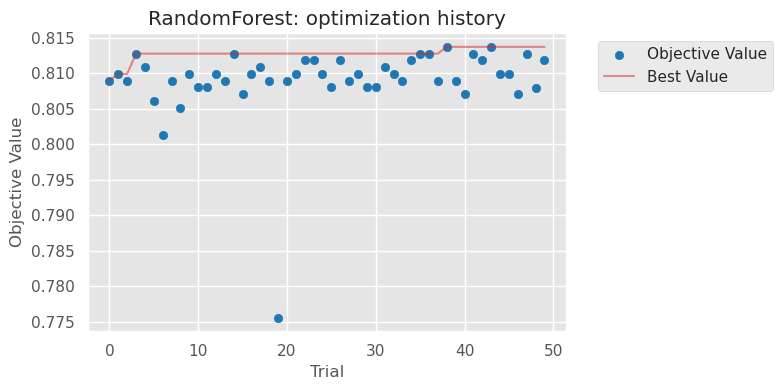

/tmp/ipykernel_33603/3885261250.py:5: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study_rf)


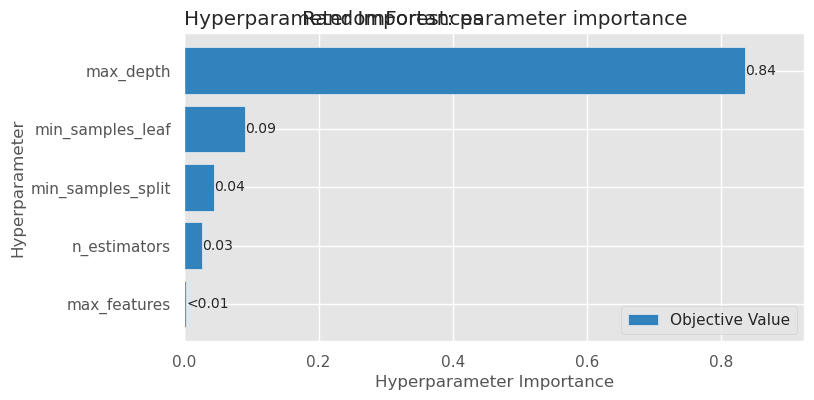

In [6]:
plot_optimization_history(study_rf)
plt.title("RandomForest: optimization history")
plt.show()

plot_param_importances(study_rf)
plt.title("RandomForest: parameter importance")
plt.show()

## HistGradientBoosting


In [7]:
def objective_hgb(trial):
    model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", HistGradientBoostingClassifier(
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3),
            max_depth=trial.suggest_int("max_depth", 2, 15),
            max_leaf_nodes=trial.suggest_int("max_leaf_nodes", 10, 100),
            min_samples_leaf=trial.suggest_int("min_samples_leaf", 5, 50),
            l2_regularization=trial.suggest_float("l2_regularization", 0.0, 10.0),
            random_state=42
        ))
    ])

    return cross_val_score(
        model, X_train, y_train,
        cv=5, scoring="accuracy", n_jobs=-1
    ).mean()


study_hgb = get_or_run_study("hgb", objective_hgb, n_trials=50)

print("Best score:", study_hgb.best_value)
print("Best params:", study_hgb.best_params)

[hgb] загружен из кэша (50 trials) — тюнинг пропущен.
Best score: 0.817552973342447
Best params: {'learning_rate': 0.06972437006239854, 'max_depth': 3, 'max_leaf_nodes': 49, 'min_samples_leaf': 13, 'l2_regularization': 4.799708823701076}


/tmp/ipykernel_33603/915168542.py:1: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study_hgb)


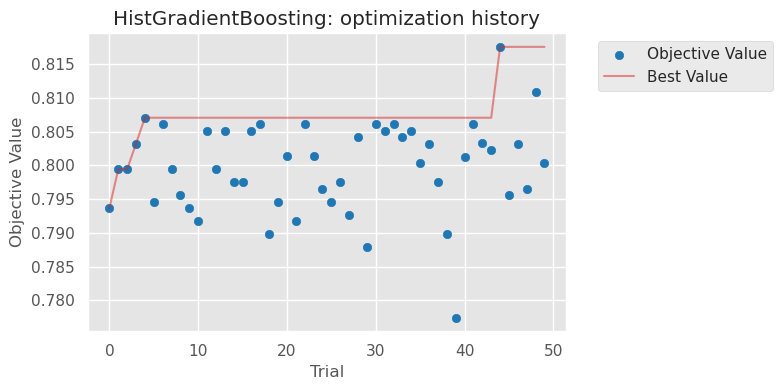

/tmp/ipykernel_33603/915168542.py:5: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study_hgb)


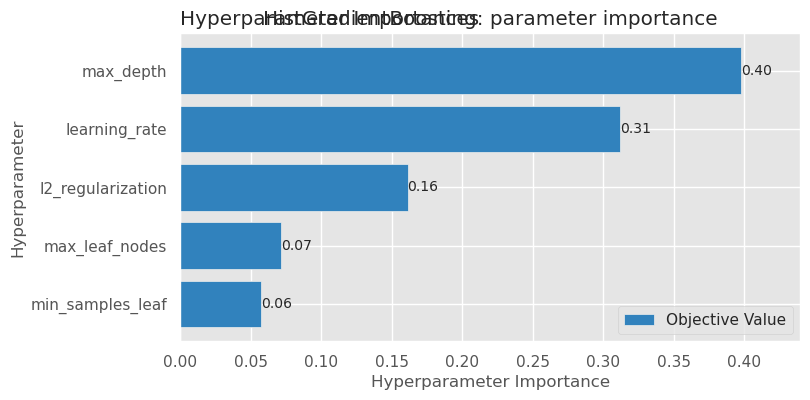

In [8]:
plot_optimization_history(study_hgb)
plt.title("HistGradientBoosting: optimization history")
plt.show()

plot_param_importances(study_hgb)
plt.title("HistGradientBoosting: parameter importance")
plt.show()

## CatBoost


In [9]:
def objective_cat(trial):
    return cross_val_score(
        Pipeline([
            ("preprocessor", preprocessor),
            ("model", CatBoostClassifier(
                iterations=trial.suggest_int("iterations", 100, 1000),
                depth=trial.suggest_int("depth", 3, 10),
                learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3),
                l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1, 10),
                bagging_temperature=trial.suggest_float("bagging_temperature", 0, 10),
                random_state=42, verbose=0
            ))
        ]),
        X_train, y_train,
        cv=5, scoring="accuracy", n_jobs=-1
    ).mean()


study_cat = get_or_run_study("cat", objective_cat, n_trials=50)

print("Best score:", study_cat.best_value)
print("Best params:", study_cat.best_params)

[cat] загружен из кэша (50 trials) — тюнинг пропущен.
Best score: 0.8070357712462976
Best params: {'iterations': 907, 'depth': 5, 'learning_rate': 0.013821972170467878, 'l2_leaf_reg': 7.065234741891823, 'bagging_temperature': 5.080554710431221}


/tmp/ipykernel_33603/2609850441.py:1: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study_cat)


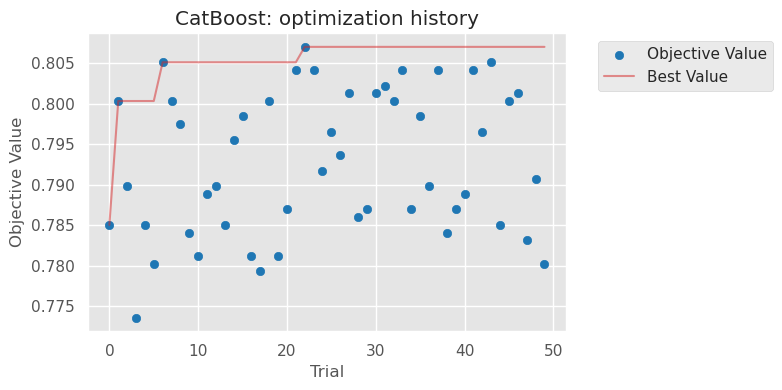

/tmp/ipykernel_33603/2609850441.py:5: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study_cat)


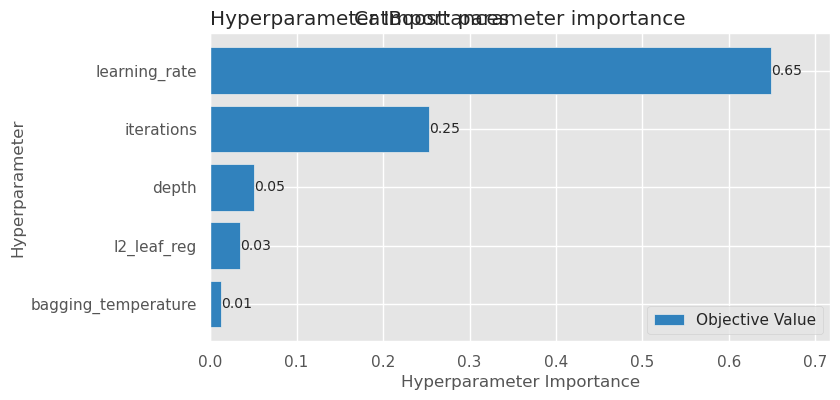

In [10]:
plot_optimization_history(study_cat)
plt.title("CatBoost: optimization history")
plt.show()

plot_param_importances(study_cat)
plt.title("CatBoost: parameter importance")
plt.show()

## Ручной RF / Manual RF baseline

RandomForest с параметрами, подобранными вручную в ноутбуке 02 —  рядом с Optuna-моделями для сравнения.


In [11]:
# Настроенный вручную RF (параметры из ноутбука 02) / hand-tuned RF baseline
rf_tuned = RandomForestClassifier(
    n_estimators=1000,
    max_depth=8,
    min_samples_leaf=3,
    min_samples_split=10,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
)

rf_tuned_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", rf_tuned),
])

# CV на тех же 5 фолдах, что и Optuna-модели / same 5-fold CV as the tuned models
rf_tuned_scores = cross_val_score(
    rf_tuned_pipe, X_train, y_train, cv=5, scoring="accuracy", n_jobs=-1
)
rf_tuned_cv = rf_tuned_scores.mean()

# Test accuracy / тестовая точность
rf_tuned_pipe.fit(X_train, y_train)
rf_tuned_test = accuracy_score(y_test, rf_tuned_pipe.predict(X_test))

print(f"CV accuracy  : {rf_tuned_cv:.4f} ± {rf_tuned_scores.std():.4f}")
print(f"Test accuracy: {rf_tuned_test:.4f}")

CV accuracy  : 0.8137 ± 0.0229
Test accuracy: 0.8511


## Best Model / Лучшая модель


In [12]:
results = pd.DataFrame([
    {"model": "RandomForest (manual)", "cv_score": rf_tuned_cv},
    {"model": "RandomForest", "cv_score": study_rf.best_value},
    {"model": "HistGradientBoosting", "cv_score": study_hgb.best_value},
    {"model": "CatBoost", "cv_score": study_cat.best_value}
])

results = results.sort_values("cv_score", ascending=False)

display(results)

,model,cv_score
2,HistGradientBoosting,0.817553
0,RandomForest (manual),0.813748
1,RandomForest,0.813734
3,CatBoost,0.807036


In [13]:
# Авто-лидер по CV (только для справки) / CV leader, for reference only
print("CV leader:", results.iloc[0]["model"])

# Финальную модель фиксируем = RandomForest: этого требует тестовое задание,
# а её CV в пределах шума от лидера / RandomForest is mandated by the task.
best_model_name = "RandomForest"
print("Final model (по заданию):", best_model_name)

CV leader: HistGradientBoosting
Final model (по заданию): RandomForest


In [14]:
# Финальные модели с параметрами, подобранными Optuna / final models with tuned params
final_models = {
    "RandomForest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(**study_rf.best_params, random_state=42, n_jobs=-1)),
    ]),
    "HistGradientBoosting": Pipeline([
        ("preprocessor", preprocessor),
        ("model", HistGradientBoostingClassifier(**study_hgb.best_params, random_state=42)),
    ]),
    "CatBoost": Pipeline([
        ("preprocessor", preprocessor),
        ("model", CatBoostClassifier(**study_cat.best_params, random_state=42, verbose=0)),
    ]),
}

In [15]:
# Обучаем и сохраняем все три финальные модели / fit & save all three models
fitted_models = {}
for name, model in final_models.items():
    path = MODELS_DIR / f"model_{name}.pkl"
    if path.exists():
        fitted_models[name] = joblib.load(path)
        print(f"[{name}] загружен из кэша.")
    else:
        model.fit(X_train, y_train)
        joblib.dump(model, path)
        fitted_models[name] = model
        print(f"[{name}] обучен и сохранён → {path.name}")

# Финальная модель задания (RandomForest) дублируется в best_model.pkl —
# его грузит ноутбук 05 / required final model also saved as best_model.pkl
best_model = fitted_models[best_model_name]
joblib.dump(best_model, MODELS_DIR / "best_model.pkl")
print("Final model:", best_model_name, "→ best_model.pkl")

best_model

[RandomForest] обучен и сохранён → model_RandomForest.pkl
[HistGradientBoosting] обучен и сохранён → model_HistGradientBoosting.pkl
[CatBoost] обучен и сохранён → model_CatBoost.pkl
Final model: RandomForest → best_model.pkl


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## Test Metrics / Метрики


In [16]:
# Test accuracy по всем финальным моделям / test accuracy for all final models
test_acc = {
    name: accuracy_score(y_test, model.predict(X_test))
    for name, model in fitted_models.items()
}
test_acc["RandomForest (manual)"] = rf_tuned_test

for name, acc in test_acc.items():
    print(f"{name:22s}: {acc:.4f}")

# отдельная переменная для финальной модели / single var for the chosen model
test_accuracy = test_acc[best_model_name]

RandomForest          : 0.8435
HistGradientBoosting  : 0.8321
CatBoost              : 0.8511
RandomForest (manual) : 0.8511


In [17]:
summary = pd.DataFrame([
    {"model": "RandomForest (manual)", "cv_score": rf_tuned_cv},
    {"model": "RandomForest", "cv_score": study_rf.best_value},
    {"model": "HistGradientBoosting", "cv_score": study_hgb.best_value},
    {"model": "CatBoost", "cv_score": study_cat.best_value},
])

summary["test_accuracy"] = summary["model"].map(test_acc)

display(summary.sort_values("cv_score", ascending=False).round(4))

,model,cv_score,test_accuracy
2,HistGradientBoosting,0.8176,0.8321
0,RandomForest (manual),0.8137,0.8511
1,RandomForest,0.8137,0.8435
3,CatBoost,0.8070,0.8511


## Входы, выходы и выводы / Inputs, outputs & conclusions

- Вход: `data/titanic_fe.parquet` и train/test split из предыдущего шага.
- Выход: `models/study_*.pkl`, три финальные модели `models/model_*.pkl`, `models/best_model.pkl` (RandomForest — по требованию задания) и test accuracy по всем трём.
- Вывод: Optuna подбирает параметры для трёх сильных моделей; ручной RF из ноутбука 02 добавлен в сравнение как baseline. Финальной берём RandomForest (требование задания), остальные две сохраняем для сравнения. Кэш защищает ноутбук от лишнего повторного обучения при следующих запусках.


Финальный вывод по проекту
В проекте решалась классическая задача бинарной классификации (выживание пассажиров Titanic). Пройден полный цикл: EDA → feature engineering → обучение нескольких моделей → тюнинг гиперпараметров.

Результаты. Все четыре модели (RandomForest, HistGradientBoosting, CatBoost) показали близкое качество: CV ≈ 0.81, test accuracy ≈ 0.83–0.85. Лучший результат на отложенной выборке — 0.8511 (RandomForest manual и CatBoost).

Главные наблюдения:

Модели практически неразличимы по качеству — разброс между ними укладывается в шум маленького датасета (test ≈ 0.4% на один объект).
Тюнинг через Optuna не улучшил RandomForest относительно ручных параметров — потолок упирается в данные и признаки, а не в гиперпараметры.
Оценку стоит делать по CV, а не по одиночному hold-out: на test'е ранжирование моделей нестабильно.